# Predicting the information for one patient

In [3]:
from tara_preprocessing import full_preprocessing,make_rbf_correlation_matrix,get_just_ecog_data,get_electrode_normalized_loc
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
print(scipy.__version__)

1.15.3


### Loading in data

In [4]:
correlation_matrix = np.load("/Users/noahwanless/Desktop/Spring2026/M467/gitproject/SuperEeg-M467-project/correlation_matrix.npy")
#^ above is the BIG correlation matrix of all the patients based on some code Tara made
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
xyz_clean, mapping_clean, kept_global_indices, cleaned = full_preprocessing(ecogs,xyz) #this fully preprocesses the data
#correlation_matrices = make_rbf_correlation_matrix(xyz_clean,cleaned,mapping_clean) #makes the big correlation matrixs  but here im loading it in

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

### Prediction function
We are trying in this example to predict for one patient

we pretend they only have 9 known electrodes that they observed (electrodes 0-9) for patient 0, while the next 30 or so we do actually know but we predent not to for the sake of comparasion, the names of the vars are similar to the eqaution from the paper

In [ ]:
def single_patient_prediction(patient,electrodestart,electrodeend,ecogs,correlation_matrix):
    #this gets everything for this patient, the correlation of the observed and unobserved datapoints
    Y = ecogs[patient] #gets this paitents data
    row_means = np.mean(Y, axis=0, keepdims=True)
    row_stds = np.std(Y, axis=0, keepdims=True)
    Y_z_score = (Y - row_means) / row_stds #turns them into there z_score for each value in the data
    print('Y_z_score.shape')
    print(Y_z_score.shape)
    K_patient = correlation_matrix[:,electrodestart:electrodeend] #this gets all the electrodes that the patient has with their own correlation and that of others
    print('K_patient.shape')
    print(K_patient.shape)
    Kalpha_alpha = K_patient[electrodestart:electrodeend,:] #gets all the rows that the patient has observed data for
    print('Kalpha_alpha.shape')
    print(Kalpha_alpha.shape)
    if electrodestart == 0:
        Kbeta_alpha = K_patient[electrodeend:,:] #* get all rows the patient doesnt have observed 
    else:
        Kbeta_alpha_1 = K_patient[0:electrodestart,:]
        Kbeta_alpha_2 = K_patient[electrodeend:,:]
        Kbeta_alpha = np.vstack((Kbeta_alpha_1,Kbeta_alpha_2))
    print('Kbeta_alpha.shape')
    print(Kbeta_alpha.shape)
    Y_patient = Y_z_score[:,electrodestart:electrodeend] #gets all the z_score values from electrodes the patient we did observed
    print('Y_patient.shape')
    print(Y_patient.shape)
    Y_true = Y_z_score[:,electrodeend:] #gets all the z_score values from electrodes the patient we didnt observed (for potential comparison later)
    print('Y_true.shape')
    print(Y_true.shape)
    Yt = Y_patient.T #take the transpose of it
    Kalpha_alpha_inv = np.linalg.inv(Kalpha_alpha) 
    pred = ((Kbeta_alpha@Kalpha_alpha_inv)@Yt).T #using formula from paper
    print('pred.shape')
    print(pred.shape)
    return pred, Y_z_score #! NOTE: keep the 'Y_true' in the return if you want to use for comparision purposes with know things of the patient

In terms of dimension the prediction should be (271400,498)

271400: this is the time dimensions

498: this is the number of electrodes we are trying to prediction, this will be the number of electrodes minus the number of known nodes of the patient we are predicting for.

In [11]:
pred,y_real = single_patient_prediction(0,5,15,ecogs,correlation_matrix)

Y_z_score.shape
(271400, 46)
correlation_matrix.shape
(509, 509)
K_patient.shape
(509, 10)
Kalpha_alpha.shape
(10, 10)
Kbeta_alpha.shape
(499, 10)
Y_patient.shape
(271400, 10)
Y_true.shape
(271400, 31)
pred.shape
(271400, 499)


NOTE: I dont know if this is comparing the correct nodes but i think so

In [10]:
ecogs[0].shape

(271400, 46)

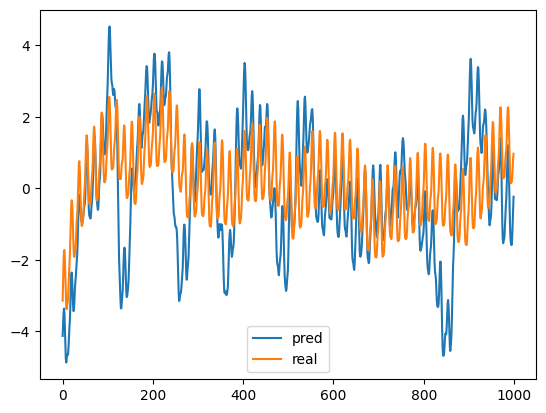

In [11]:
plt.plot(pred[2000:3000,0],label='pred')
plt.plot(y_real[2000:3000,0],label='real')
plt.legend()

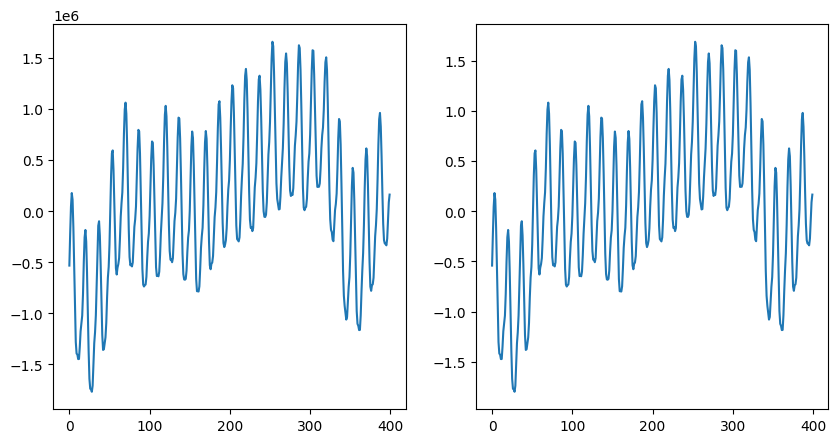

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(ecogs[0][2100:2500,0])
ax[1].plot(y_real[2100:2500,0])